<a href="https://colab.research.google.com/github/JanuNandhini/24AD004_DSV_TEAM_13/blob/main/Code_for_all_the_week.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Library Included


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

Week 2 -Dataset Description

Loading Dataset




In [ ]:

# Load CSV
df=pd.read_csv("/content/Crime_Data_from_2020_to_Present.csv")
print("Team 13 - Crime Hotspot Mapping")
print("File loaded successfully ")

Team 13 - Crime Hotspot Mapping
File loaded successfully 


Understand structure,
Detect missing values,
Identify data types,
Preview actual data

In [ ]:
print(df.dtypes)
df.head()
df.tail()
df.info()
df.isnull().sum()

DR_NO               int64
Date Rptd          object
DATE OCC           object
TIME OCC            int64
AREA              float64
AREA NAME          object
Rpt Dist No       float64
Part 1-2          float64
Crm Cd            float64
Crm Cd Desc        object
Mocodes            object
Vict Age          float64
Vict Sex           object
Vict Descent       object
Premis Cd         float64
Premis Desc        object
Weapon Used Cd    float64
Weapon Desc        object
Status             object
Status Desc        object
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION           object
Cross Street       object
LAT               float64
LON               float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109703 entries, 0 to 109702
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DR_NO           109703 non-null  int64  
 1   Date

,0
DR_NO,0
Date Rptd,0
DATE OCC,0
TIME OCC,0
AREA,1
AREA NAME,1
Rpt Dist No,1
Part 1-2,1
Crm Cd,1
Crm Cd Desc,1


Week 3-Cleaning Sprint

Displays the count of missing values in each column of the dataset.

Helps understand data quality and identify incomplete fields.

Renames important columns for better readability and easier usage:

Crm Cd Desc → Crime Description

TIME OCC → Time

DATE OCC → Date

LAT → Latitude

LON → Longitude

Removes rows where Latitude and Longitude are missing, since location is essential for spatial analysis and crime hotspot mapping.

In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())

df.rename(columns={
    'Crm Cd Desc': 'Crime Description',
    'TIME OCC': 'Time',
    'DATE OCC': 'Date',
    'LAT': 'Latitude',
    'LON': 'Longitude'
}, inplace=True)

df.dropna(subset=['Latitude', 'Longitude'], inplace=True)

Missing values before cleaning:
DR_NO                  0
Date Rptd              0
DATE OCC               0
TIME OCC               0
AREA                   1
AREA NAME              1
Rpt Dist No            1
Part 1-2               1
Crm Cd                 1
Crm Cd Desc            1
Mocodes            13813
Vict Age               1
Vict Sex           13345
Vict Descent       13348
Premis Cd              2
Premis Desc           40
Weapon Used Cd     68009
Weapon Desc        68009
Status                 1
Status Desc            1
Crm Cd 1               3
Crm Cd 2          100790
Crm Cd 3          109417
Crm Cd 4          109692
LOCATION               1
Cross Street       88943
LAT                    1
LON                    1
dtype: int64


Missing crime descriptions are replaced with "Unknown"

Missing time values are replaced using mode (most frequent value)

Date column is converted into proper datetime format

Hour is extracted from time (24-hour format)

Invalid hour values are removed

In [ ]:
df['Crime Description'] = df['Crime Description'].fillna('Unknown')

df['Time'] = df['Time'].fillna(df['Time'].mode()[0])

df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')


df['Time'] = df['Time'].astype(str).str.zfill(4)
df['Hour'] = df['Time'].str[:2].astype(int)

df = df[(df['Hour'] >= 0) & (df['Hour'] <= 23)]

A new feature called Time of Day is created to categorize crimes into Morning, Afternoon, Evening, and Night. Crime descriptions are also standardized by converting text to lowercase and removing extra spaces


In [ ]:

def time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['Time_of_Day'] = df['Hour'].apply(time_of_day)


df['Crime Description'] = df['Crime Description'].str.lower().str.strip()

Time of Day Classification

In [ ]:
crime_per_hour = df.groupby('Hour').size()

z_scores = np.abs(stats.zscore(crime_per_hour))
crime_per_hour_cleaned = crime_per_hour[z_scores < 3]


A box plot is used to visualize the distribution of crime frequency across different hours and detect outliers in the data.

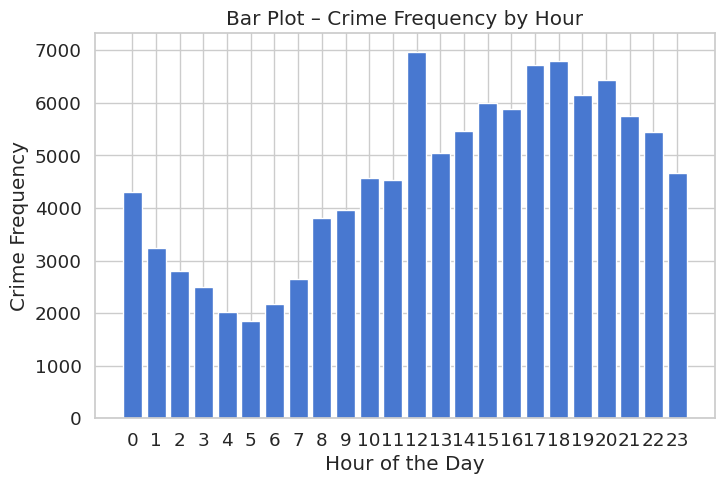

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(crime_per_hour.index, crime_per_hour.values)
plt.title("Bar Plot – Crime Frequency by Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Crime Frequency")
plt.xticks(range(0,24))
plt.show()

A bar chart is used to show how crime occurrences vary across different hours of the day, helping identify peak crime timings.




In [ ]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nCleaned dataset preview:")
print(df[['Date','Hour','Time_of_Day','Latitude','Longitude','Crime Description']].head())


Missing values after cleaning:
DR_NO                     0
Date Rptd                 0
Date                 109702
Time                      0
AREA                      0
AREA NAME                 0
Rpt Dist No               0
Part 1-2                  0
Crm Cd                    0
Crime Description         0
Mocodes               13812
Vict Age                  0
Vict Sex              13344
Vict Descent          13347
Premis Cd                 1
Premis Desc              39
Weapon Used Cd        68008
Weapon Desc           68008
Status                    0
Status Desc               0
Crm Cd 1                  2
Crm Cd 2             100789
Crm Cd 3             109416
Crm Cd 4             109691
LOCATION                  0
Cross Street          88942
Latitude                  0
Longitude                 0
Hour                      0
Time_of_Day               0
dtype: int64

Cleaned dataset preview:
  Date  Hour Time_of_Day  Latitude  Longitude  \
0  NaT    21       Night   34.0375  -118

Final check for the cleaned dataset

Week 4- Exploratory Data Analysis (EDA)

In [ ]:
df = pd.read_csv("/content/final_cleaned_crime_data.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("\n--- DATA INFO ---")
print(df.info())

print("\n--- SHAPE ---")
print(df.shape)

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- FIRST 5 ROWS ---")
print(df.head())


--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4064 entries, 0 to 4063
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DR_NO              4064 non-null   int64  
 1   Date Rptd          4064 non-null   object 
 2   Date               4064 non-null   object 
 3   Time               4064 non-null   int64  
 4   AREA               4064 non-null   int64  
 5   Area Name          4064 non-null   object 
 6   Rpt Dist No        4064 non-null   int64  
 7   Part 1-2           4064 non-null   int64  
 8   Crm Cd             4064 non-null   int64  
 9   Crime Description  4064 non-null   object 
 10  Vict Age           4064 non-null   int64  
 11  Vict Sex           4064 non-null   object 
 12  Vict Descent       4064 non-null   object 
 13  Premis Cd          4064 non-null   int64  
 14  Premis Desc        4060 non-null   object 
 15  Status             4064 non-null   object 
 16  Statu

DATA INFO,
MISSING VALUES,
FIRST 5 ROWS in the Cleaned Dataset



In [ ]:
# Convert date columns
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], errors='coerce')

# Remove invalid locations
df = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)]

# Handle missing values
df['Vict Sex'] = df['Vict Sex'].fillna('Unknown')
df['Vict Descent'] = df['Vict Descent'].fillna('Unknown')

# Drop rows with missing crime description
df = df.dropna(subset=['Crime Description'])

 1. Crime Type Distribution

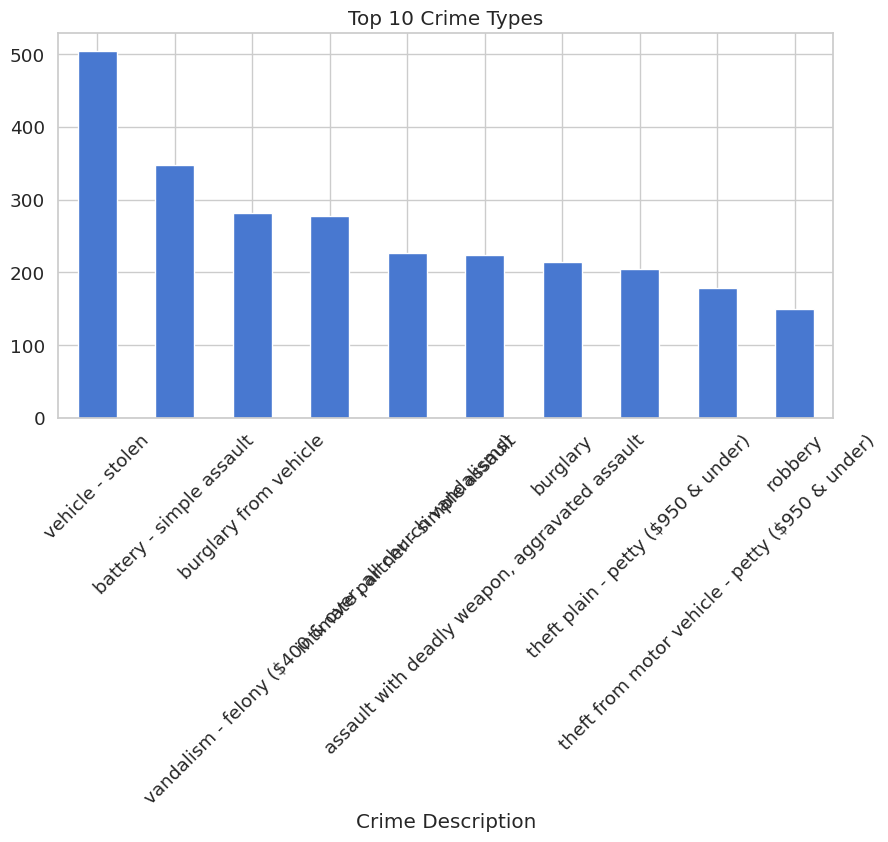

In [ ]:
plt.figure(figsize=(10,5))
df['Crime Description'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Crime Types")
plt.xticks(rotation=45)
plt.show()

 2. Area Distribution

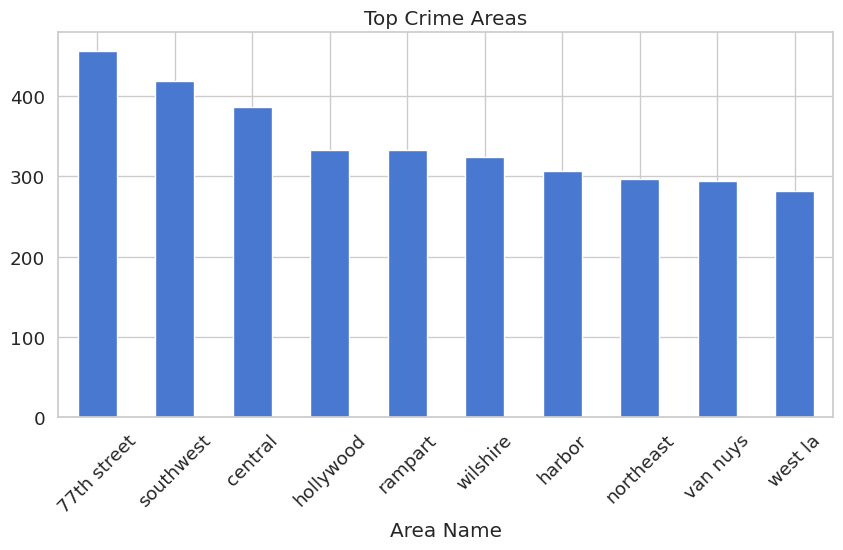

In [ ]:
plt.figure(figsize=(10,5))
df['Area Name'].value_counts().head(10).plot(kind='bar')
plt.title("Top Crime Areas")
plt.xticks(rotation=45)
plt.show()

3. Time of Day Distribution

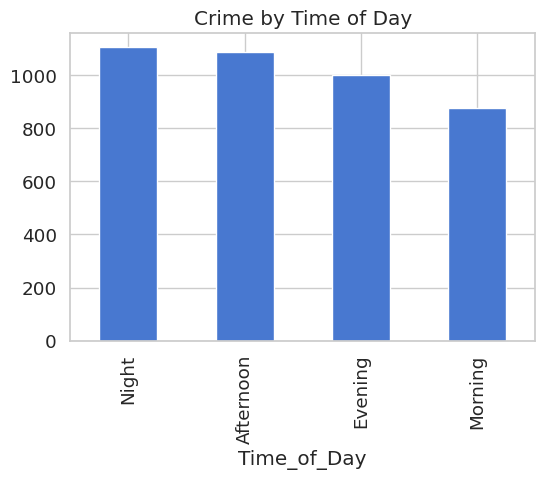

In [ ]:
plt.figure(figsize=(6,4))
df['Time_of_Day'].value_counts().plot(kind='bar')
plt.title("Crime by Time of Day")
plt.show()

4.Victim Age Distribution

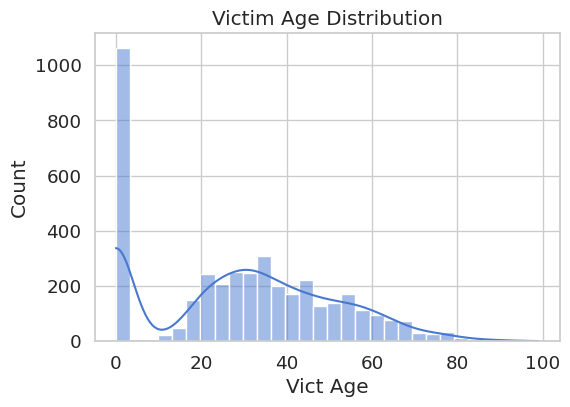

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Vict Age'], bins=30, kde=True)
plt.title("Victim Age Distribution")
plt.show()

 5.Crime by Month

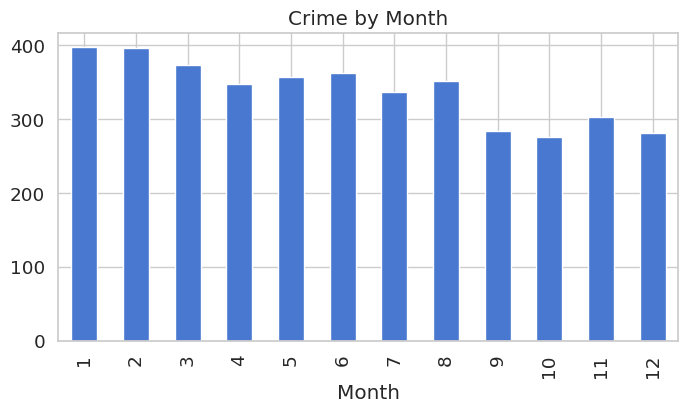

In [ ]:
plt.figure(figsize=(8,4))
df['Month'].value_counts().sort_index().plot(kind='bar')
plt.title("Crime by Month")
plt.show()

6. Crime by Weekday

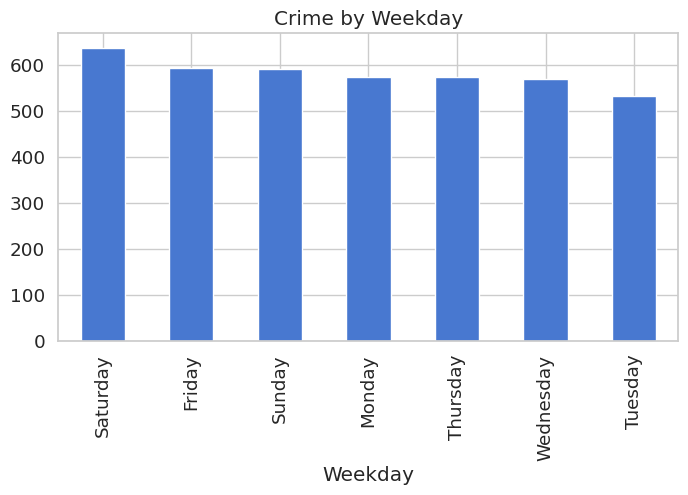

In [ ]:
plt.figure(figsize=(8,4))
df['Weekday'].value_counts().plot(kind='bar')
plt.title("Crime by Weekday")
plt.show()


 7. Crime by Hour

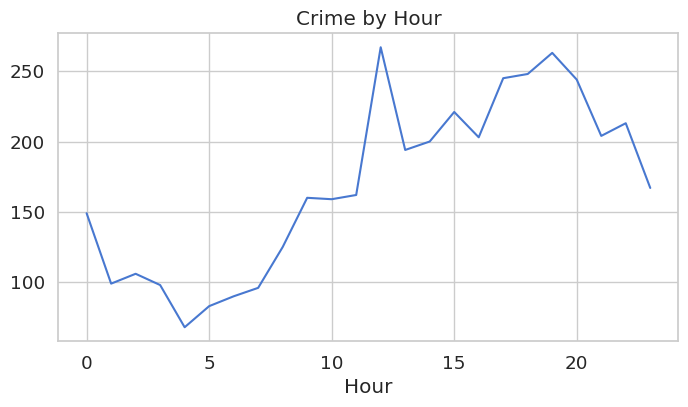

In [ ]:
plt.figure(figsize=(8,4))
df['Hour'].value_counts().sort_index().plot()
plt.title("Crime by Hour")
plt.show()


 8. Crime Type vs Area


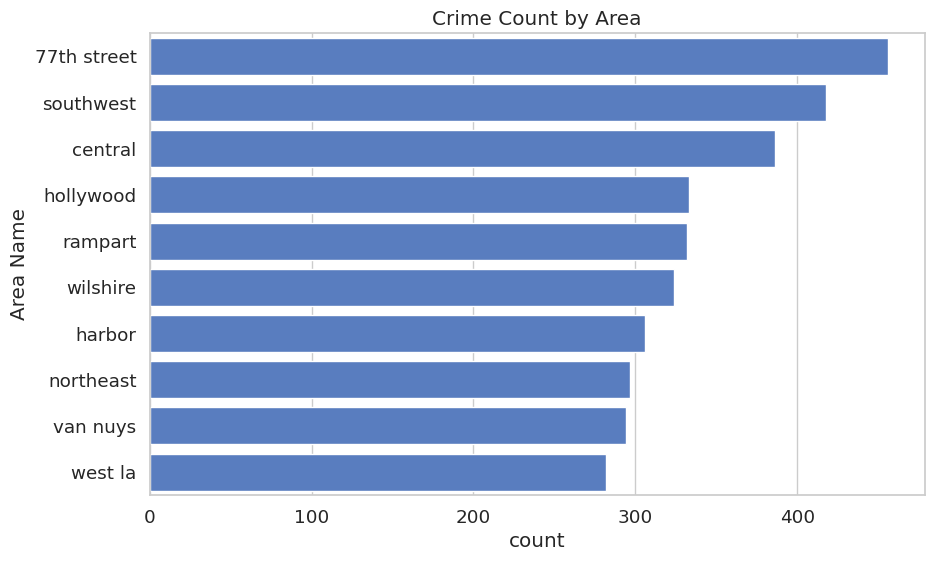

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Area Name',
              order=df['Area Name'].value_counts().index[:10])
plt.title("Crime Count by Area")
plt.show()


9. Crime Type vs Time of Day

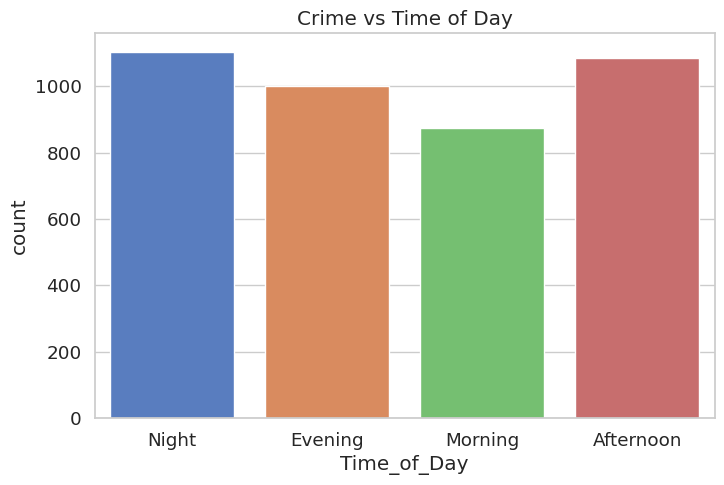

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Time_of_Day', hue='Time_of_Day')
plt.title("Crime vs Time of Day")
plt.show()


10. Vict Age vs Crime Type

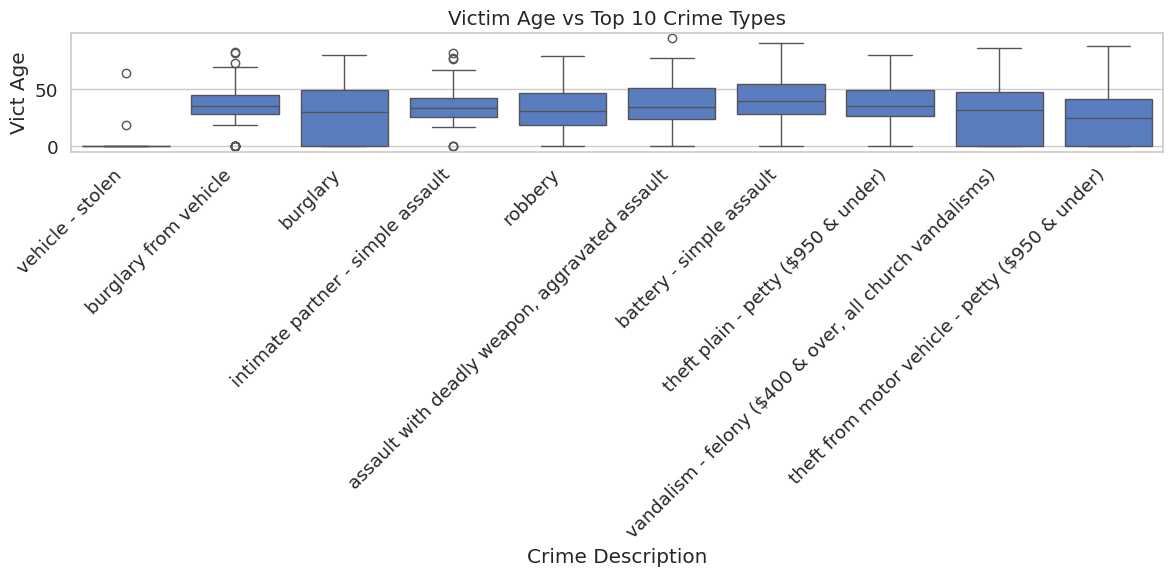

In [ ]:
plt.figure(figsize=(12,6))

top_crimes = df['Crime Description'].value_counts().head(10).index

sns.boxplot(
    data=df[df['Crime Description'].isin(top_crimes)],
    x='Crime Description',
    y='Vict Age'
)

plt.xticks(rotation=45, ha='right')
plt.title("Victim Age vs Top 10 Crime Types")
plt.tight_layout()
plt.show()


 11. Crime Trend Over Time

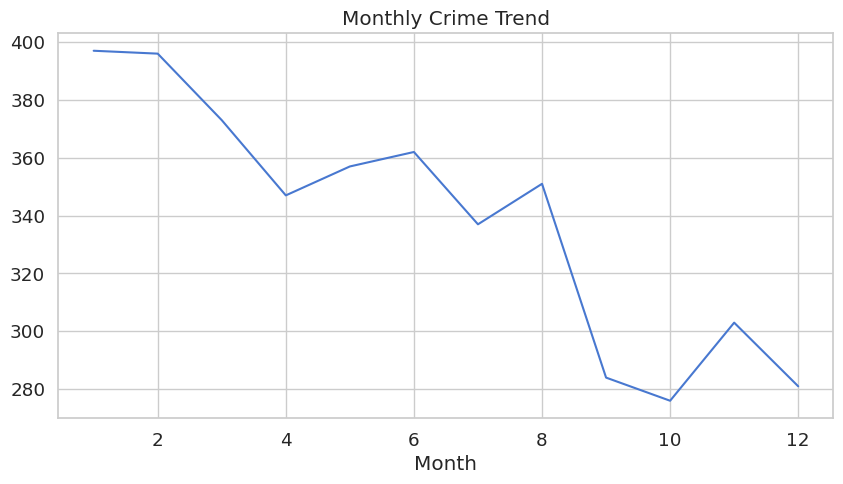

In [ ]:
plt.figure(figsize=(10,5))
df.groupby('Month').size().plot()
plt.title("Monthly Crime Trend")
plt.show()

 12. Crime by Area and Time

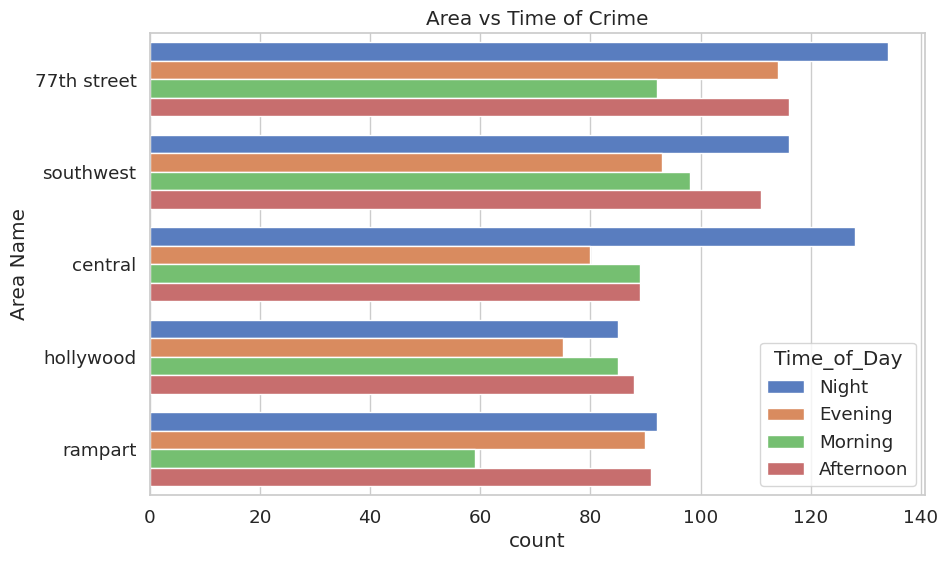

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Area Name', hue='Time_of_Day',
              order=df['Area Name'].value_counts().index[:5])
plt.title("Area vs Time of Crime")
plt.show()

13. Vict Sex Distribution

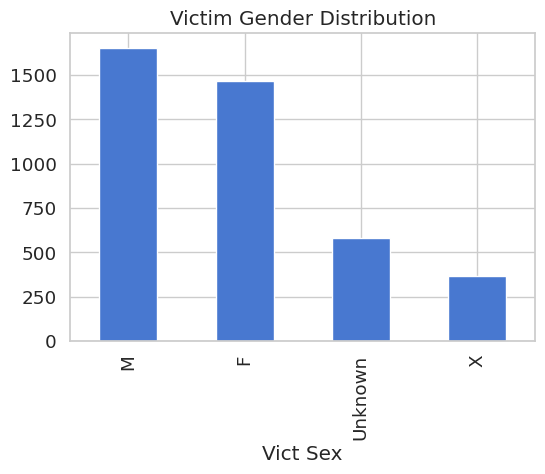

In [ ]:
plt.figure(figsize=(6,4))
df['Vict Sex'].value_counts().plot(kind='bar')
plt.title("Victim Gender Distribution")
plt.show()

14. Crime by Victim Descent

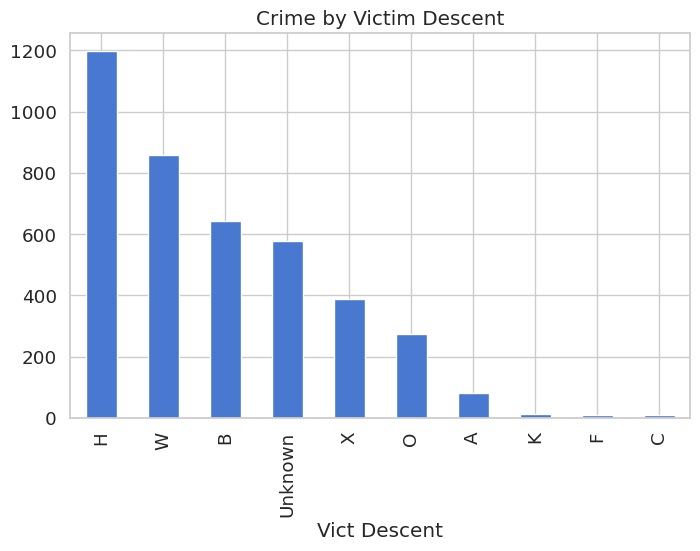

In [ ]:
plt.figure(figsize=(8,5))
df['Vict Descent'].value_counts().head(10).plot(kind='bar')
plt.title("Crime by Victim Descent")
plt.show()

15. Scatter Plot (Location Pattern)

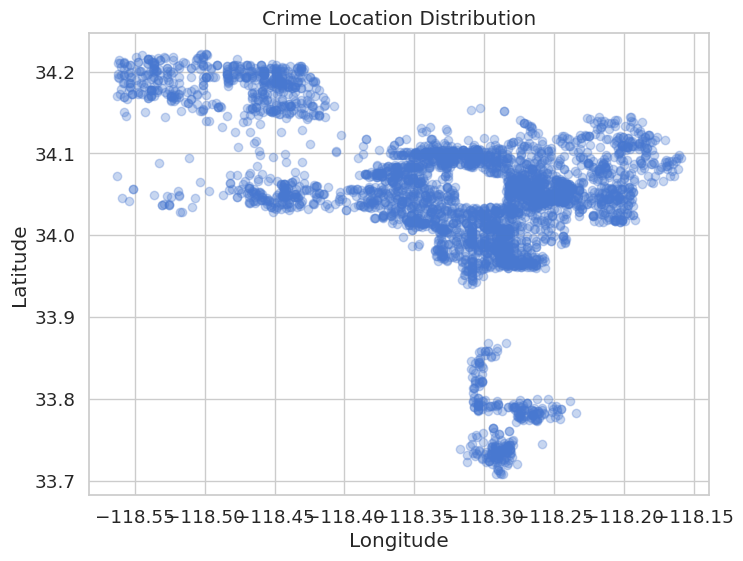

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.3)
plt.title("Crime Location Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

FULL FEATURE HEATMAP (CLEAR)

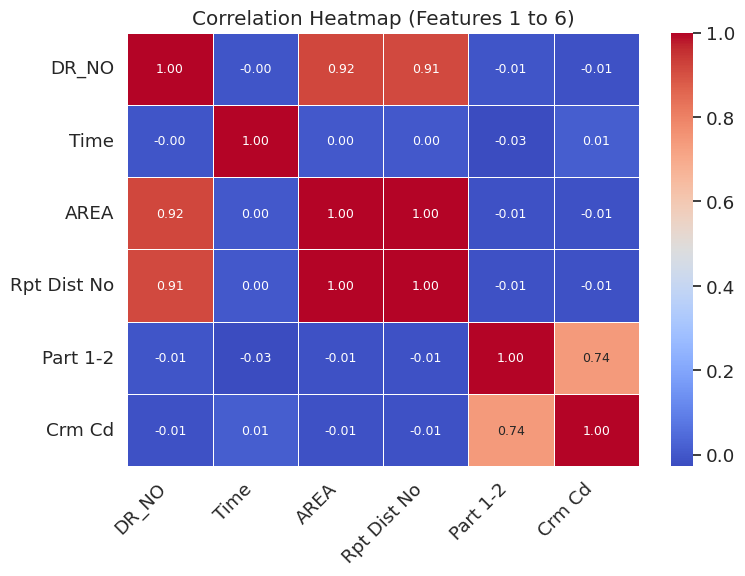

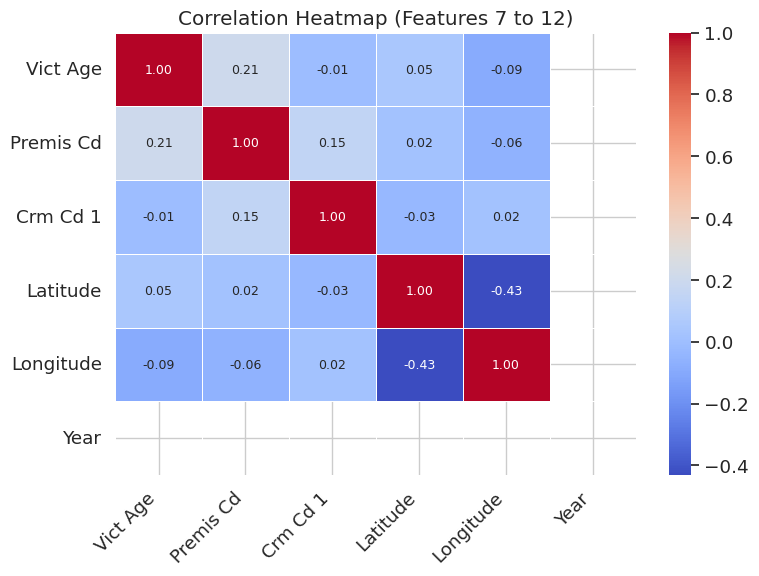

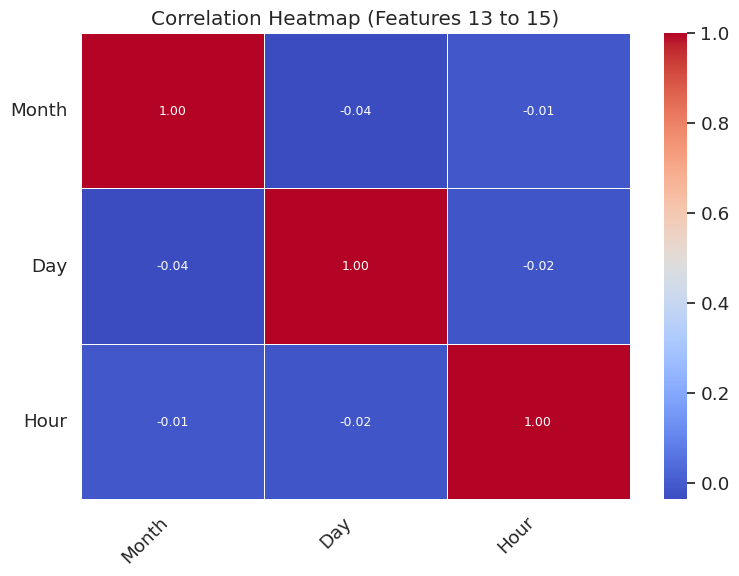

In [ ]:
# Get numeric columns
num_cols = df.select_dtypes(include='number').columns.tolist()

# Function to plot subset heatmaps
def plot_subset_heatmaps(df, cols, group_size=6):
    for i in range(0, len(cols), group_size):
        subset = cols[i:i+group_size]
        corr = df[subset].corr()

        plt.figure(figsize=(8, 6))

        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5,
            annot_kws={"size": 9}
        )

        plt.title(f"Correlation Heatmap (Features {i+1} to {i+len(subset)})")
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

# Call function
plot_subset_heatmaps(df, num_cols, group_size=6)

Data Insights

In [ ]:
print("\n--- TOP 5 CRIME AREAS ---")
print(df['Area Name'].value_counts().head())

print("\n--- TOP 5 CRIME TYPES ---")
print(df['Crime Description'].value_counts().head())

print("\n--- PEAK CRIME TIME ---")
print(df['Time_of_Day'].value_counts())

print("\n--- SUMMARY STATISTICS ---")
print(df.describe())


--- TOP 5 CRIME AREAS ---
Area Name
77th street    456
southwest      418
central        386
hollywood      333
rampart        332
Name: count, dtype: int64

--- TOP 5 CRIME TYPES ---
Crime Description
vehicle - stolen                                           504
battery - simple assault                                   347
burglary from vehicle                                      281
vandalism - felony ($400 & over, all church vandalisms)    277
intimate partner - simple assault                          226
Name: count, dtype: int64

--- PEAK CRIME TIME ---
Time_of_Day
Night        1104
Afternoon    1085
Evening      1000
Morning       875
Name: count, dtype: int64

--- SUMMARY STATISTICS ---
              DR_NO                      Date Rptd  \
count  4.064000e+03                           1588   
mean   2.006720e+08  2020-06-26 15:26:45.037783552   
min    1.903265e+08            2020-01-01 00:00:00   
25%    2.003166e+08            2020-04-03 00:00:00   
50%    2.007008e+08    

Final Dataset

In [ ]:
df.to_csv("week5_ready_dataset.csv", index=False)

print("\n Week 5 dataset ready!")


 Week 5 dataset ready!


Week 6-Data Transformation and Feature Engineering

Identify the Column types

In [ ]:
# Keep original for comparison
df_original = df.copy()

print("Original Shape:", df.shape)

# -------------------------------
# 2. IDENTIFY COLUMNS
# -------------------------------
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Categorical Columns:", cat_cols)


Original Shape: (4064, 27)
Categorical Columns: ['Area Name', 'Crime Description', 'Vict Sex', 'Vict Descent', 'Premis Desc', 'Status', 'Status Desc', 'LOCATION', 'Weekday', 'Time_of_Day']


Encoding

In [ ]:
le_dict = {}  # store encoders for future use

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("After Label Encoding Shape:", df.shape)

After Label Encoding Shape: (4064, 27)


Handle Skewness

Feature Scaling

In [ ]:
skew_before = df[num_cols].skew()

skewed_cols = skew_before[abs(skew_before) > 0.5].index

columns_to_exclude_from_log = ['Latitude', 'Longitude']
skewed_cols = [col for col in skewed_cols if col not in columns_to_exclude_from_log]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

print("Skewed columns fixed:", list(skewed_cols))

Skewed columns fixed: ['DR_NO']


In [ ]:
# Standardization
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

# (Optional) MinMax scaling version
minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[num_cols] = minmax.fit_transform(df[num_cols])

Visualization

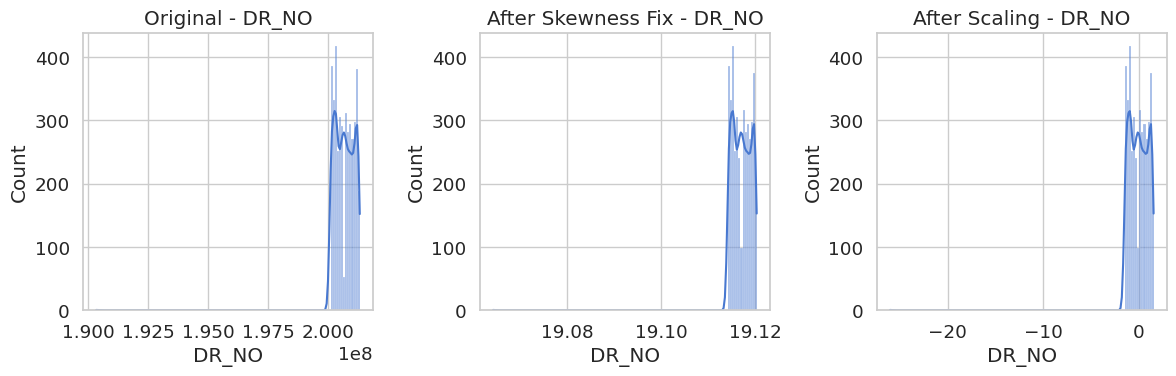

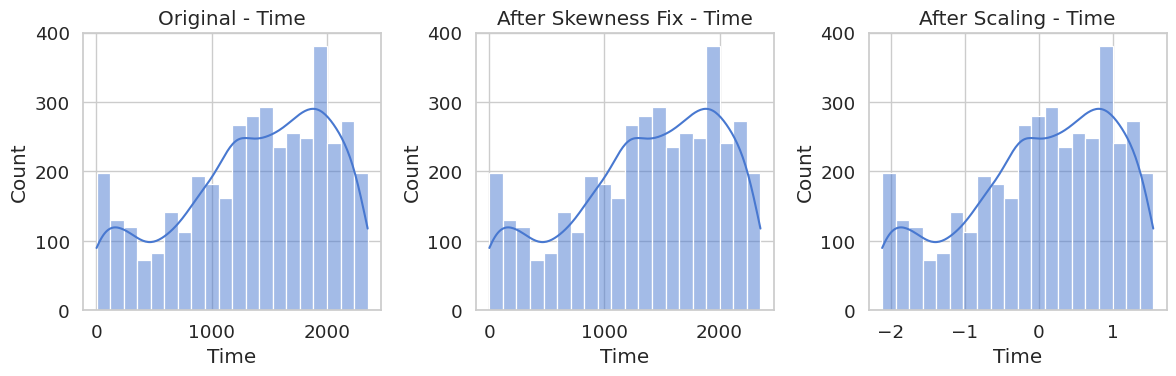

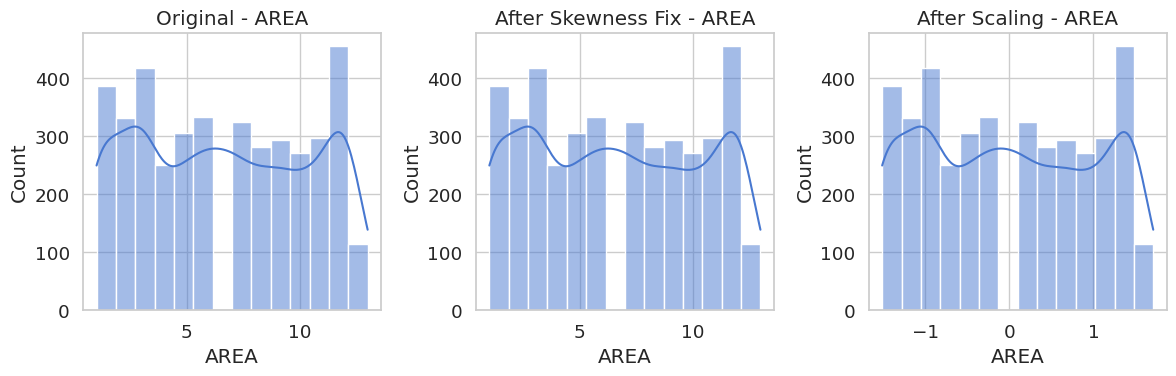

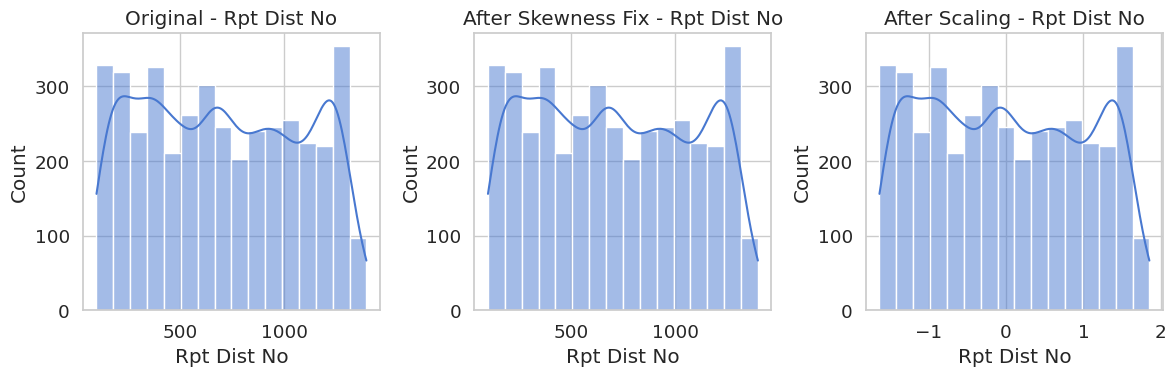

In [ ]:
sample_cols = num_cols[:4] if len(num_cols) >= 4 else num_cols

for col in sample_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.histplot(df_original[col], kde=True)
    plt.title(f'Original - {col}')

    plt.subplot(1,3,2)
    sns.histplot(df[col], kde=True)
    plt.title(f'After Skewness Fix - {col}')

    plt.subplot(1,3,3)
    sns.histplot(df_scaled[col], kde=True)
    plt.title(f'After Scaling - {col}')

    plt.tight_layout()
    plt.show()

In [ ]:
print("Final Dataset Shape:", df_scaled.shape)

df_scaled.head()

Final Dataset Shape: (4064, 27)


,DR_NO,Date Rptd,Date,Time,AREA,Area Name,Rpt Dist No,Part 1-2,Crm Cd,Crime Description,...,Crm Cd 1,LOCATION,Latitude,Longitude,Year,Month,Day,Weekday,Hour,Time_of_Day
0,-26.054416,2020-01-03,2020-01-03,1.188489,0.099900,12,0.204565,-0.834786,-0.007758,82,...,-0.006041,963,-0.084661,-0.307779,0.0,-0.908341,-1.659242,3,1.167199,3
1,-1.387454,2020-09-02,2020-08-02,0.676573,-1.512258,1,-1.419286,-0.834786,-0.878565,13,...,-0.877684,125,-0.015098,0.697381,0.0,-1.200183,-0.869314,2,0.702484,1
2,-0.862520,2020-11-11,2020-04-11,0.521447,-0.974872,8,-0.949934,-0.834786,-0.152892,7,...,-0.151315,523,-0.251007,0.269215,0.0,1.426388,-1.320702,6,0.547579,1
3,0.577730,2023-10-05,2020-10-03,1.044222,0.637287,9,0.690102,-0.834786,-0.815673,61,...,-0.814732,547,1.126140,-1.316372,0.0,-0.908341,-0.643621,5,1.012294,1
4,-0.635701,2020-09-09,2020-09-09,-1.138399,-0.706179,3,-0.796180,-0.834786,-0.007758,82,...,-0.006041,1026,0.363971,1.267505,0.0,0.842706,-0.756468,6,-1.156374,2


Week 7-Feature Selection and PCA

Numeric Shape: (4064, 25)


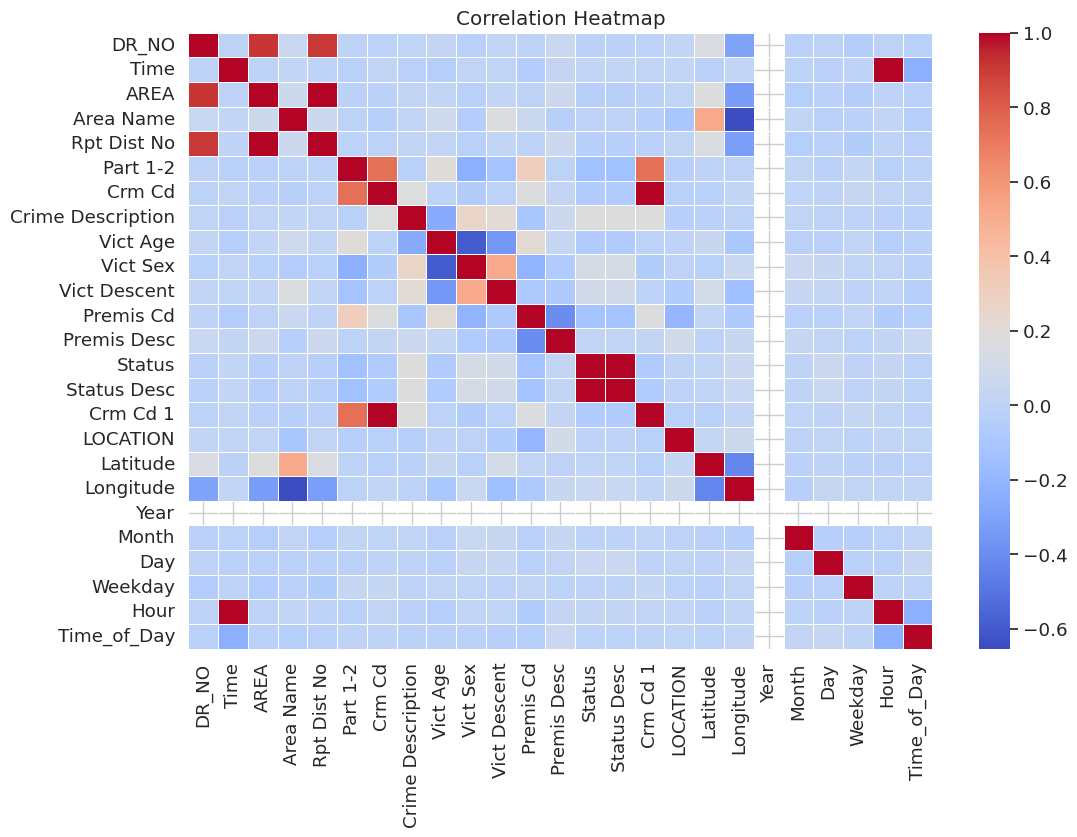

After Feature Selection: (4064, 21)
PCA Shape: (4064, 21)


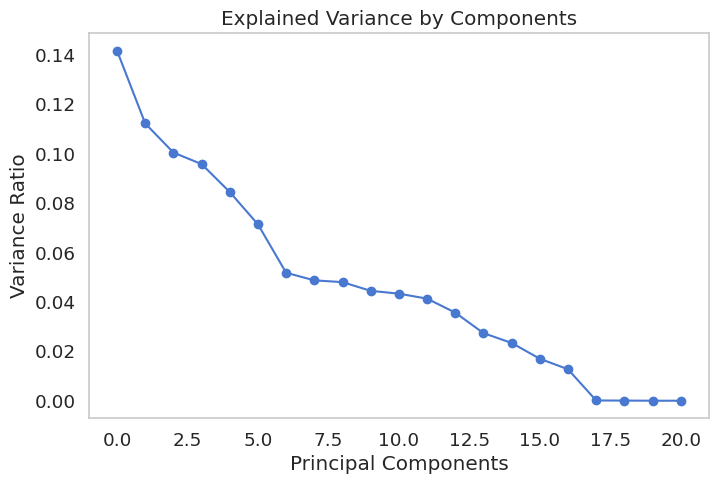

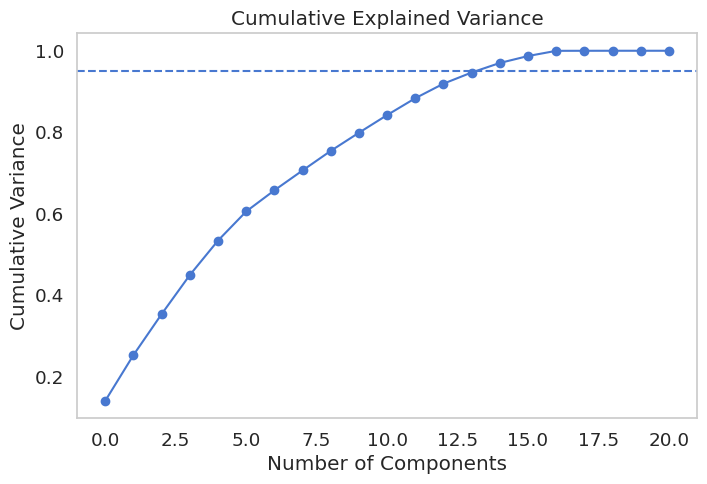

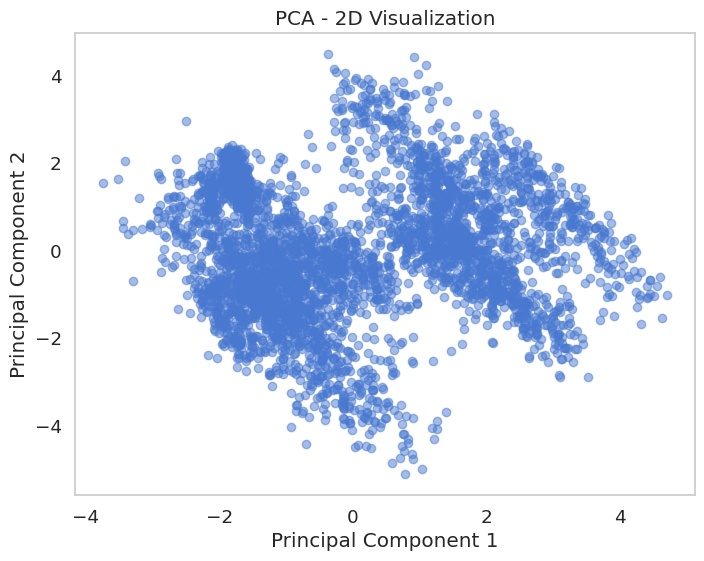

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

df_numeric = df.select_dtypes(include=[np.number])

print("Numeric Shape:", df_numeric.shape)

plt.figure(figsize=(12, 8))
corr_matrix = df_numeric.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


selector = VarianceThreshold(threshold=0.01)
df_selected = selector.fit_transform(df_numeric)

# Convert back to DataFrame
selected_columns = df_numeric.columns[selector.get_support()]
df_selected = pd.DataFrame(df_selected, columns=selected_columns)

print("After Feature Selection:", df_selected.shape)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_selected)


pca = PCA()
pca_data = pca.fit_transform(scaled_data)

print("PCA Shape:", pca_data.shape)

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(explained_variance, marker='o')
plt.title("Explained Variance by Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.grid()
plt.show()


cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o')
plt.axhline(y=0.95, linestyle='--')  # 95% threshold
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid()
plt.show()


pca_final = PCA(n_components=2)
pca_2d = pca_final.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_2d, columns=['PC1', 'PC2'])


plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.5)
plt.title("PCA - 2D Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

- Low-variance + SelectKBest for feature selection
- PCA shows how many components capture most variance
- 2D projection for visual clustering

You can now experiment with different `k`, targets, or add more features (e.g., one-hot encoding).